Estimated mu_Z = 0.997106, Theory mu_Z = 1.000000
Estimated sigma_Z = 1.710659, Theory sigma_Z = 1.732051


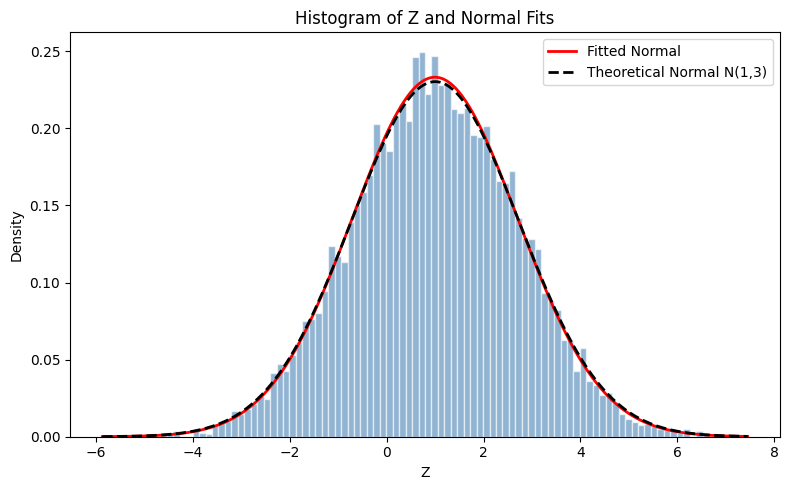

In [3]:
import numpy as np  
import matplotlib.pyplot as plt  
from math import sqrt, pi, exp  

# Parameters  
N = 10000  # Number of samples
np.random.seed(0)  

# Simulate data
X = np.random.normal(loc=0.0, scale=1.0, size=N)  
Y = np.random.normal(loc=1.0, scale=np.sqrt(2.0), size=N)  
Z = X + Y  

# Estimate Parameters  
mu_hat = Z.mean()  
sigma_hat = Z.std(ddof=1)  

# Theoretical Parameters  
mu_theory = 1.0  
sigma2_theory = 3.0  
sigma_theory = sqrt(sigma2_theory)  

# Output results  
print(f"Estimated mu_Z = {mu_hat:.6f}, Theory mu_Z = {mu_theory:.6f}")  
print(f"Estimated sigma_Z = {sigma_hat:.6f}, Theory sigma_Z = {sigma_theory:.6f}")  

# Plot histogram  
bins = 100  
plt.figure(figsize=(8,5))  
counts, bins_edges, _ = plt.hist(Z, bins=bins, density=True, alpha=0.6, color='steelblue', edgecolor='white')  

# Overlay normal distributions  
from numpy import linspace  
z_min, z_max = Z.min(), Z.max()  
z_grid = linspace(z_min, z_max, 200)  

def normal_pdf(z, mu, sigma):  
    return (1.0/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((z-mu)/sigma)**2)  

plt.plot(z_grid, normal_pdf(z_grid, mu_hat, sigma_hat), 'r-', lw=2, label='Fitted Normal')  
plt.plot(z_grid, normal_pdf(z_grid, mu_theory, sigma_theory), 'k--', lw=2, label='Theoretical Normal N(1,3)')  

plt.title('Histogram of Z and Normal Fits')  
plt.xlabel('Z')  
plt.ylabel('Density')  
plt.legend()  
plt.tight_layout()  
plt.savefig('Z_distribution_fit.png', dpi=300, bbox_inches='tight')  

plt.show() 